### Exploring Wildfire-Ignition Data

Our Wildfire dataset combines meteorological records from [gridMET](https://www.climatologylab.org/gridmet.html) with positive wildfire ignition events provided by [IRWIN](https://www.wildfire.gov/application/irwin-integrated-reporting-wildfire-information), along with synthesized negative events. Each sample corresponds to a 75-day window: 60 days pre-ignition ("Wildfire" column labeled "No"), day of ignition (labeled "Yes"), and 14 days post-ignition (labeled "No"). We want to use this data to predict wildfire risk.

#### Outcome Variable and Signficance
Our dependent variable is the probability of ignition within the next 60 days. By making our outcome variable reflect temporal data, we will allow our model to account for metereological patterns that our daily records may not capture. Further, we aim to check against our geographic clusters to see if different regions have other meaningful differences that aren't reflected in the variables we track. 

Predicting this variable is crucial for directing fire minimization risks (like collecting fuel), safeguarding communities at risk, and devising evacuation plans. 


#### Expectations
This outcome matches our expectation that wildfire risk is highly dependent on short-term environmental factors. Hence, measuring wildfire risk in terms time to ignition provides a more actionable metric for fire management.

#### What are your key explanatory variables?

While we collect a variety of meteorological records, our preliminary analysis indicates that Wind Speed, Minimum Relative Humidity and the 100-hour Fuel Moisture variables are the most influential in determining wildfire ignition risk. We also suspect the rest of the variables described in our Codebook (`data/README.md`) will be helpful in making these predictions. Here's a copy of said codebook:
| Variable | Name                         | Units  | Description                                                                                                                               |
| -------- | ---------------------------- | ------ | ----------------------------------------------------------------------------------------------------------------------------------------- |
| `pr`     | Precipitation                | mm/day | Total daily precipitation (including rain and snow). Higher precipitation tends to increase fuel moisture and thus reduce wildfire risk.                        |
| `rmax`   | Maximum Relative Humidity    | %      | Highest daily relative humidity. This is the peak atmospheric moisture; higher relative humidity reduces fire intensity.                               |
| `rmin`   | Minimum Relative Humidity    | %      | Lowest daily relative humidity. Low-humidity areas are more likely to have dried-out fuel which increases ignition risk and the potential of the fire to spread.                   |
| `sph`    | Specific Humidity            | kg/kg  | Mass of water vapor per unit mass of air. Describes atmospheric moisture content independent of temperature.                               |
| `srad`   | Solar Radiation              | W/m^2   | Incoming solar energy at the surface. Higher solar radiation promotes fuel dryness and increases surface temperatures and, hence, ignition risk.                                    |
| `tmmn`   | Minimum Temperature          | °C     | Lowest daily air temperature. Affects how much moisture fuel can retain overnight.                                                  |
| `tmmx`   | Maximum Temperature          | °C     | Highest daily air temperature. Higher values promote dryness and increase ignition risk.                                                        |
| `vs`     | Wind Speed                   | m/s    | Average wind speed. Strong winds tends to increase fire intensity and contribute to fires spreading.                                                       |
| `bi`     | Burning Index                | Index  | Fire danger index (based on factors like fuel conditions and weather). Higher values correspond to harder fire control.                              |
| `fm100`  | 100-hour Fuel Moisture       | %      | Moisture content of medium-sized fuels, such as small branches. Affected by weather after approximately [100 hours](https://www.nwcg.gov/publications/pms437/fuel-moisture/dead-fuel-moisture-content).                                       |
| `fm1000` | 1000-hour Fuel Moisture      | %      | Moisture content of large fuels, such as logs. Changes slowly, responding to the weather after approximately 1000 hours (associated with long-term dry conditions).                                    |
| `erc`    | Energy Release Component     | Index  | Composite index describing potential heat output from a fire. Higher values correspond to more intense ignition events.                                |
| `etr`    | Reference Evapotranspiration | mm/day | Estimated water loss from a reference surface, such as grass. Describes how much moisture the atmosphere can absorb.                                    |
| `pet`    | Potential Evapotranspiration | mm/day | Maximum possible evapotranspiration under ideal conditions. Indicates how dry the environment can become.                                |
| `vpd`    | Vapor Pressure Deficit       | kPa    | Difference between actual and saturated vapor pressure. High VPD shows that there's dry air and strong evaporative demand. |

### Data Wrangling

While we provide a more thorough description of our dataset and preprocessing in `data/README.md`, here's a brief outline of our preprocessing. 

Since the original dataset includes 126,800 labeled samples (~2 GiB of data), we limited our data to the calendar year of 2025 to make analysis feasible. Further, we removed invalid rows containing equal 32,767 (the maximum value of a 16-bit two's complement integer), because those are invalid entries as we explain in `clean_data.ipynb`. We also removed an unnamed column field left over in the original data.

However, our data was mostly well formatted with dates appearing in a year-month-day format, and filled-in numeric values (whose units we know from the dataset's documentation). 

Since the variables included in our data appear to be good predictors of wildfires according to our research, we haven't added any new variables for meteorological data. The only exception is our inclusion of a `region` variable for later analysis. We're still deciding if we want to use human-created geographical clusters (Southwest, Midwest, etc.) versus creating geographic clusters through K-means and then assigning human-readable labels. We're leaning toward the latter approach as we think these clusters represent wildfire data more faithfully. Finally, using these clusters we want to determine if there are regional variations in wildfire risks for which our current variables don't account. For instance, we want to see if our model's prediction changes significantly when making prediction in the Northeast vs South California.

#### Summary Statistics

### Data Visualization

You must include at least 4 visualizations of your data. You must include your outcome variable in at least two plots and your key explanatory variable in at least two of these plots. You must use visualizations that are appropriate for the data type (categorical vs numeric, continuous vs discrete) of your outcome and explanatory variables. For example, you should not use a histogram to plot a categorical variable.

We start out by importing our dependencies:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.cluster import KMeans

# Make images non pixelated: https://stackoverflow.com/a/49684115
%config InlineBackend.figure_format = 'svg'

Then, we import the raw data:

In [2]:
wildfires_raw = pd.read_csv('../data/wildfires_2025.csv')

Then, we clean up the data (same code as `clean_data.ipynb`) by dropping invalid rows and an unnamed column, and print summary statistics

In [3]:
# Identity invalid rows (rows with the value of 32,767 in any column)
valid_rows = wildfires_raw.agg(lambda rows: np.all(rows != 32767), axis="columns")
print(f"Dropping {np.logical_not(valid_rows).sum()} invalid rows")

# Drop invalid rows and the "unnamed" column.
wildfires = wildfires_raw[valid_rows] \
    .drop(columns="Unnamed: 0") \
    .reset_index(drop=True) 

print(f"Wildfire df shape {wildfires_raw.shape} -> {wildfires.shape}")
# Describe data set
wildfires.describe()

Dropping 699 invalid rows
Wildfire df shape (19210, 20) -> (18511, 19)


,latitude,longitude,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
count,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000,18511.000000
mean,37.083158,-105.387942,1.342450,71.406029,34.447836,0.003095,123.474048,272.708946,284.613414,4.004532,35.696721,13.485841,15.024364,42.701637,3.236006,2.082281,0.638108
std,3.433801,15.684500,5.608602,25.724255,20.773964,0.001815,38.944902,8.045034,9.389356,1.943776,26.430696,5.499349,5.859116,27.420492,2.097680,1.268413,0.486186
min,27.040306,-123.521655,0.000000,6.600000,1.000000,0.000240,21.600000,243.900000,250.600000,0.500000,0.000000,2.700000,4.100000,0.000000,0.100000,0.100000,0.000000
25%,34.009100,-118.143780,0.000000,52.100000,16.900000,0.001720,101.400000,267.700000,277.450000,2.500000,21.000000,8.300000,8.900000,21.000000,1.600000,1.100000,0.220000
50%,36.639766,-116.501730,0.000000,78.000000,34.200000,0.002650,127.800000,274.500000,287.400000,3.700000,30.000000,14.500000,17.100000,32.000000,2.700000,1.800000,0.540000
75%,40.061456,-89.392520,0.000000,94.500000,50.200000,0.004080,149.000000,278.900000,291.600000,5.100000,52.000000,18.100000,19.800000,69.000000,4.700000,3.000000,0.960000
max,47.951750,-69.803039,119.700000,100.000000,100.000000,0.014250,277.600000,298.100000,304.000000,16.400000,153.000000,28.200000,34.300000,107.000000,11.800000,8.000000,2.370000


Then, we'll group our data into geographic clusters using K-means:

In [4]:
# Get active wildfires' coordinates
wildfires_active = wildfires[wildfires['Wildfire'] == 'Yes']
wildfires_coords = wildfires_active[['latitude', 'longitude']]
# Fit coordinates into 6 clusters.
kmeans = KMeans(n_clusters=6, random_state=30, n_init="auto").fit(wildfires_coords)
# Add clusters back to data frame
wildfires_clustered = wildfires_active.assign(cluster = kmeans.labels_)

By analyzing the clusters we got (in `clustering.ipynb`) we assigned some labels to each of these clusters:

In [5]:
wildfire_regions = wildfires_clustered.assign(
    region = wildfires_clustered['cluster'].map({
        0: 'Southwest', 1: 'Northeast', 2: 'Southern California', 3: 'Great Plains', 4: 'Southeast', 5: 'Pacific Northwest'
    }))

fig = px.scatter_map(
    wildfire_regions, lat="latitude", lon="longitude", color="region",
    # Center on the US and set default zoom
    center={'lat': 39.8283, 'lon':-98.5795}, zoom=3,
    # Visual configuration
    color_discrete_sequence=px.colors.qualitative.Plotly,
    # Add title, subtitle, legend
    title="Wildfire Labeled Geographic Clusters",
    subtitle="K-means clustering of wildfire ignition events based on geographic coordinates.",
    labels={"region": "Wildfire Region", 'latitude': "Latitude"})

# Add x/y axis labels 
fig.add_annotation(
    text="Longitude →", xref="paper", yref="paper",
    x=0.5, y=-0.05, showarrow=False, font=dict(size=12)
)
fig.add_annotation(
    text="↑ Latitude", xref="paper", yref="paper",
    x=-0.05, y=0.5, showarrow=False, textangle=-90, font=dict(size=12)
)

fig.show()

Based on these geographic clusters, we can count the wildfire ignition events:

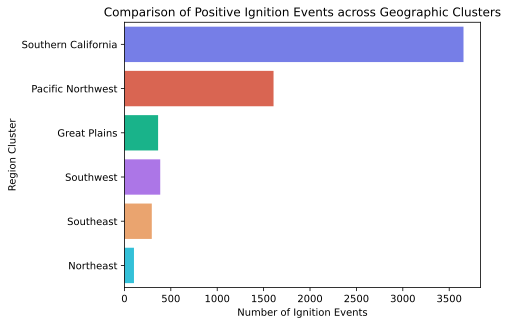

In [21]:
# Group clusters
cluster_counts = wildfire_regions.groupby("region").size()

# Plot counts
ax = sns.countplot(
    # Display regions vertically for readability. Use same colors as before (just 6 clusters).
    wildfire_regions, y="region", hue="region", palette=px.colors.qualitative.Plotly[:6])

# Set labels
_ = ax.set(
    title="Comparison of Positive Ignition Events across Geographic Clusters",
    ylabel = "Region Cluster", xlabel = "Number of Ignition Events")
